# Morphology Analysis

**Author:** Kevin Druciak (kevintdruciak@gmail.com)

Quantitative analysis of neurons segmented from the ISBI 2012 *Drosophila* ssTEM dataset. Per-neuron volume, surface area, equivalent diameter, and sphericity with distribution plots and 3D centroid visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from scipy.ndimage import gaussian_filter, distance_transform_edt, binary_fill_holes
from skimage.exposure import equalize_adapthist
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.measure import regionprops_table, marching_cubes, mesh_surface_area
from skimage.color import label2rgb
import pandas as pd

## Segment ISBI 2012 Volume

In [2]:
volume = imread("../sample_data/isbi2012/train-volume.tif")
voxel_spacing = np.array([0.050, 0.004, 0.004])  # Z=50nm, YX=4nm in micrometers

smoothed = gaussian_filter(volume.astype(np.float64) / 255.0, sigma=1.0)
chunk_size = max(1, min(volume.shape) // 4)
equalized = equalize_adapthist(smoothed, kernel_size=chunk_size, clip_limit=0.03)
rescaled = (equalized * 255).astype(np.uint8)
membrane_mask = rescaled < 100
interior = ~membrane_mask
distance = distance_transform_edt(interior)
min_dist = max(5, int(0.02 * min(volume.shape)))
coords = peak_local_max(distance, min_distance=min_dist, labels=interior.astype(int))
markers = np.zeros_like(membrane_mask, dtype=np.int32)
for i, c in enumerate(coords, start=1):
    markers[tuple(c)] = i
labels = watershed(-distance, markers, mask=interior)

# Cleanup
for lbl in np.unique(labels):
    if lbl == 0:
        continue
    if (labels == lbl).sum() < 500:
        labels[labels == lbl] = 0
for lbl in np.unique(labels):
    if lbl == 0:
        continue
    mask = labels == lbl
    filled = binary_fill_holes(mask)
    labels[filled & (labels == 0)] = lbl

print(f"Segmented {len(np.unique(labels)) - 1} neurons from ISBI 2012 volume")

Segmented 2708 neurons from ISBI 2012 volume


## Per-Neuron Statistics

In [3]:
props = regionprops_table(
    labels,
    properties=("label", "area", "centroid", "bbox", "equivalent_diameter_area"),
    spacing=voxel_spacing,
)
df = pd.DataFrame(props)
df = df.rename(columns={
    "area": "volume_um3",
    "centroid-0": "centroid_z_um",
    "centroid-1": "centroid_y_um",
    "centroid-2": "centroid_x_um",
    "equivalent_diameter_area": "equiv_diameter_um",
})

surface_areas = []
for lbl in df["label"]:
    binary = (labels == lbl).astype(np.uint8)
    try:
        verts, faces, _, _ = marching_cubes(binary, level=0.5, spacing=voxel_spacing)
        sa = mesh_surface_area(verts, faces)
    except Exception:
        sa = 0.0
    surface_areas.append(sa)

df["surface_area_um2"] = surface_areas
df["sphericity"] = (
    (np.pi ** (1/3) * (6 * df["volume_um3"]) ** (2/3)) / df["surface_area_um2"]
).clip(0, 1)

print(f"Computed stats for {len(df)} neurons")
df.head(10)

Computed stats for 2708 neurons


,label,volume_um3,centroid_z_um,centroid_y_um,centroid_x_um,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,equiv_diameter_um,surface_area_um2,sphericity
0,1,0.004533,0.649965,1.379167,1.239311,2,331,289,30,361,329,0.205332,0.447265,0.296140
1,2,0.003970,1.057334,0.118586,1.445033,9,13,344,30,48,379,0.196462,0.405682,0.298897
2,3,0.002547,1.044755,0.280353,1.126377,13,55,266,30,83,295,0.169442,0.260168,0.346688
3,4,0.003601,0.875905,1.834448,0.661243,9,442,154,29,476,184,0.190166,0.381346,0.297919
4,5,0.001243,1.005824,0.642762,0.107048,12,150,17,28,171,35,0.133408,0.150563,0.371357
5,6,0.004664,0.375463,0.345693,0.063055,0,70,0,21,104,31,0.207294,0.398153,0.339058
6,7,0.001970,0.362099,0.715945,0.391199,0,168,86,19,195,109,0.155544,0.223929,0.339425
7,8,0.001399,0.535249,1.452130,1.386760,5,355,335,20,371,358,0.138769,0.146787,0.412145
8,9,0.002068,0.647485,0.093685,1.482801,7,10,357,23,38,387,0.158070,0.223782,0.350773
9,10,0.004440,0.899207,1.088450,0.369861,7,258,77,29,290,108,0.203921,0.422844,0.308953


## Size Distributions

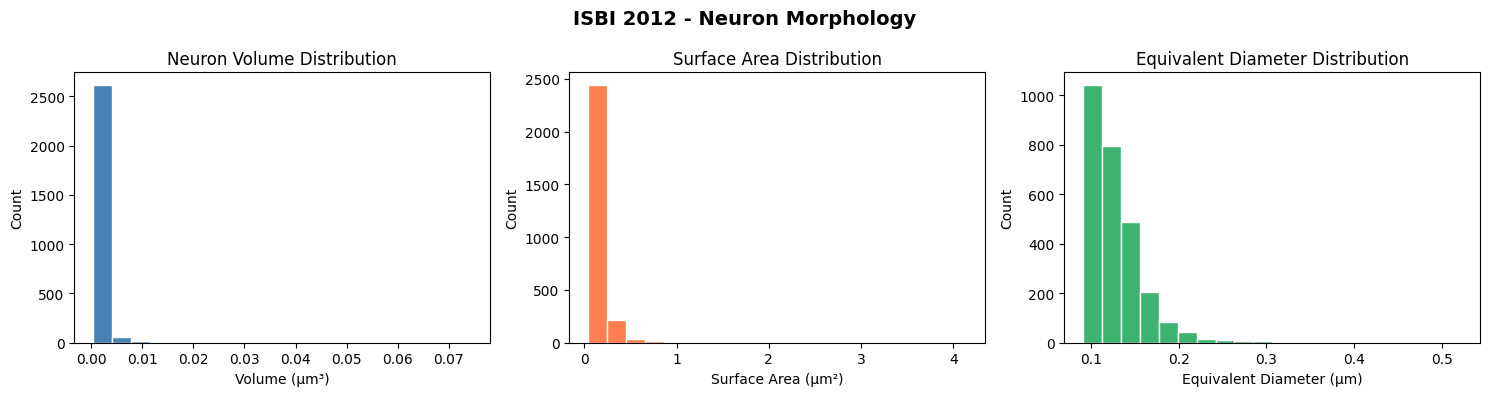

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["volume_um3"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Volume (\u03bcm\u00b3)")
axes[0].set_ylabel("Count")
axes[0].set_title("Neuron Volume Distribution")

axes[1].hist(df["surface_area_um2"], bins=20, color="coral", edgecolor="white")
axes[1].set_xlabel("Surface Area (\u03bcm\u00b2)")
axes[1].set_ylabel("Count")
axes[1].set_title("Surface Area Distribution")

axes[2].hist(df["equiv_diameter_um"], bins=20, color="mediumseagreen", edgecolor="white")
axes[2].set_xlabel("Equivalent Diameter (\u03bcm)")
axes[2].set_ylabel("Count")
axes[2].set_title("Equivalent Diameter Distribution")

plt.suptitle("ISBI 2012 - Neuron Morphology", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Volume vs. Surface Area

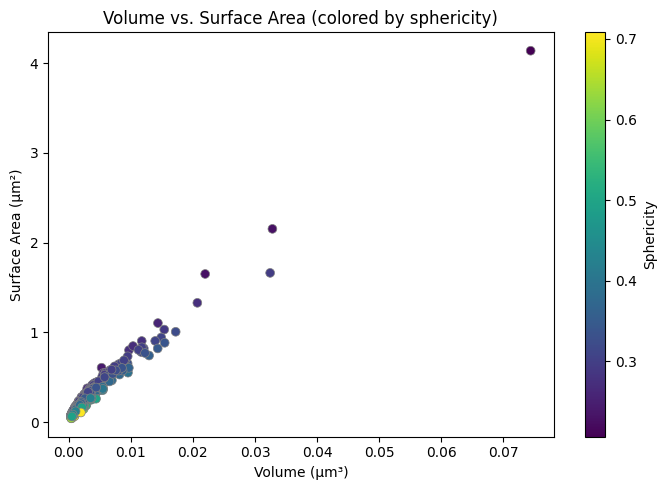

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    df["volume_um3"], df["surface_area_um2"],
    c=df["sphericity"], cmap="viridis", s=40, edgecolors="gray", linewidths=0.5,
)
ax.set_xlabel("Volume (\u03bcm\u00b3)")
ax.set_ylabel("Surface Area (\u03bcm\u00b2)")
ax.set_title("Volume vs. Surface Area (colored by sphericity)")
plt.colorbar(scatter, ax=ax, label="Sphericity")
plt.tight_layout()
plt.show()

## 3D Centroid Distribution

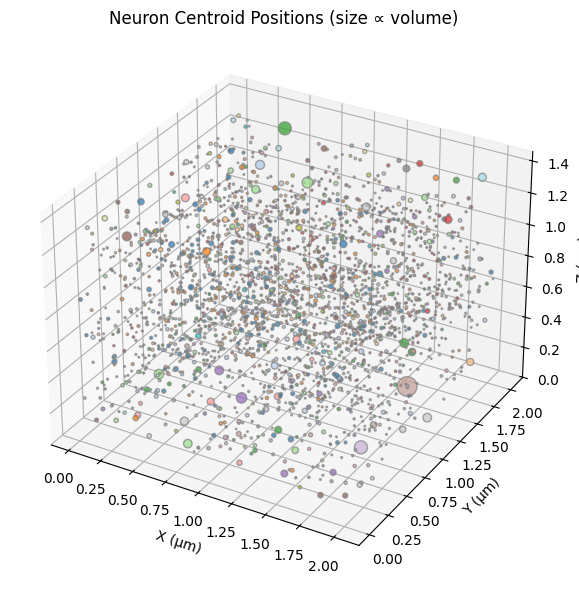

In [6]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    df["centroid_x_um"], df["centroid_y_um"], df["centroid_z_um"],
    s=df["volume_um3"] / df["volume_um3"].max() * 200,
    c=df["label"], cmap="tab20", alpha=0.7, edgecolors="gray",
)
ax.set_xlabel("X (\u03bcm)")
ax.set_ylabel("Y (\u03bcm)")
ax.set_zlabel("Z (\u03bcm)")
ax.set_title("Neuron Centroid Positions (size \u221d volume)")
plt.tight_layout()
plt.show()

## Summary Statistics

In [7]:
summary = df[["volume_um3", "surface_area_um2", "equiv_diameter_um", "sphericity"]].describe()
print(summary.to_string())

csv_path = "../output/neuron_stats.csv"
import os
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
df.to_csv(csv_path, index=False)
print(f"\nExported to {csv_path}")

        volume_um3  surface_area_um2  equiv_diameter_um   sphericity
count  2708.000000       2708.000000        2708.000000  2708.000000
mean      0.001379          0.150125           0.128086     0.389136
std       0.002234          0.141570           0.033535     0.050547
min       0.000400          0.042752           0.091416     0.206690
25%       0.000606          0.083819           0.105004     0.354620
50%       0.000915          0.117835           0.120459     0.383855
75%       0.001490          0.173153           0.141708     0.419303
max       0.074378          4.138048           0.521774     0.708103

Exported to ../output/neuron_stats.csv
